# Sales Forecasting and Trend Analysis

## Objective
Analyze historical sales performance and predict future revenue trends using machine learning.

## Business Value
Helps organizations optimize inventory planning, marketing campaigns, and financial forecasting.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

import pickle
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("sales_data.csv")

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [9]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

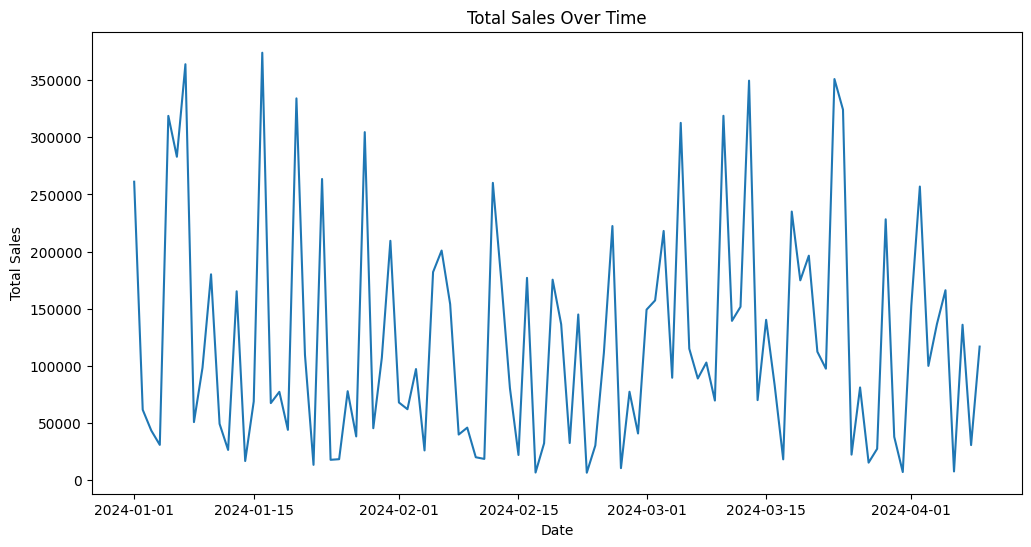

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Total_Sales'])
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

In [14]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

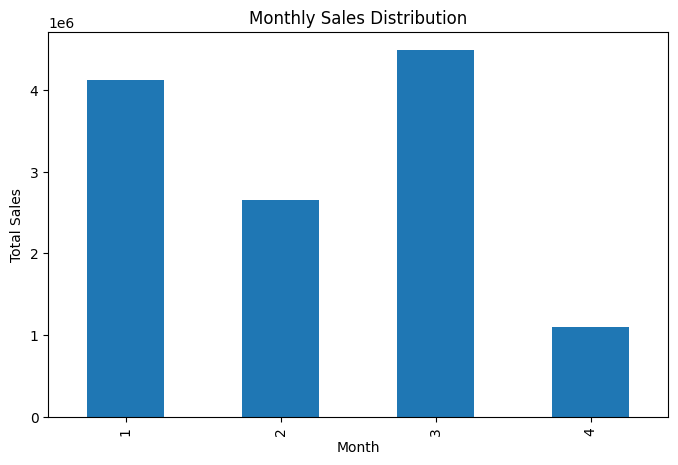

In [15]:
plt.figure(figsize=(8,5))

monthly_sales = df.groupby(df['Date'].dt.month)['Total_Sales'].sum()

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales Distribution")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

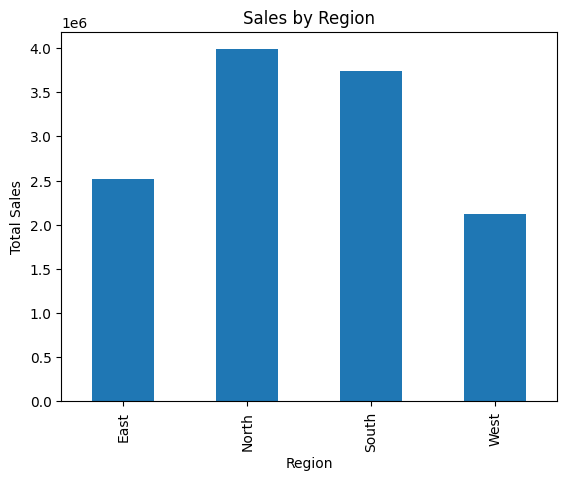

In [16]:
region_sales = df.groupby('Region')['Total_Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

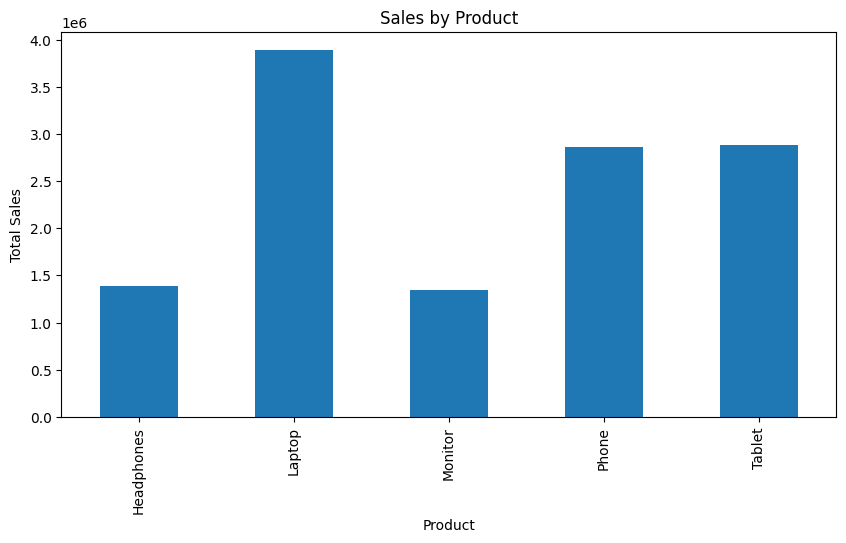

In [17]:
product_sales = df.groupby('Product')['Total_Sales'].sum()

product_sales.plot(kind='bar', figsize=(10,5))
plt.title("Sales by Product")
plt.ylabel("Total Sales")
plt.show()

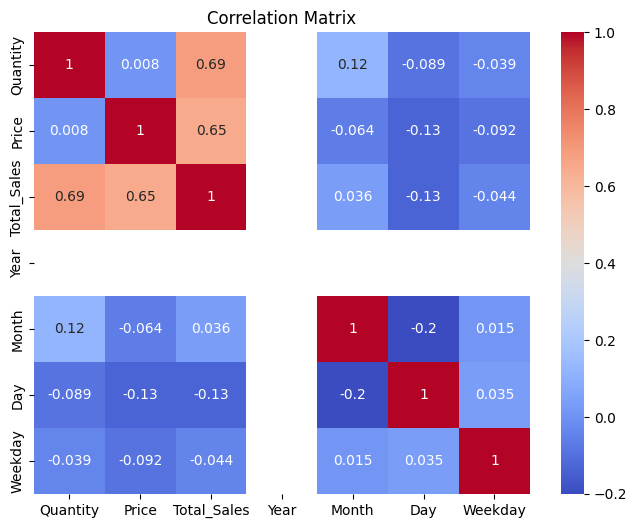

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [19]:
X = df[['Quantity', 'Price', 'Year', 'Month', 'Day', 'Weekday']]
y = df['Total_Sales']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [22]:
print("Linear Regression MAE:",
      mean_absolute_error(y_test, lr_preds))

print("Linear Regression R2 Score:",
      r2_score(y_test, lr_preds))

Linear Regression MAE: 30612.293081506767
Linear Regression R2 Score: 0.8545982348731384


In [23]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [24]:
print("Random Forest MAE:",
      mean_absolute_error(y_test, rf_preds))

print("Random Forest R2 Score:",
      r2_score(y_test, rf_preds))

Random Forest MAE: 21215.946000000004
Random Forest R2 Score: 0.9245646987573037


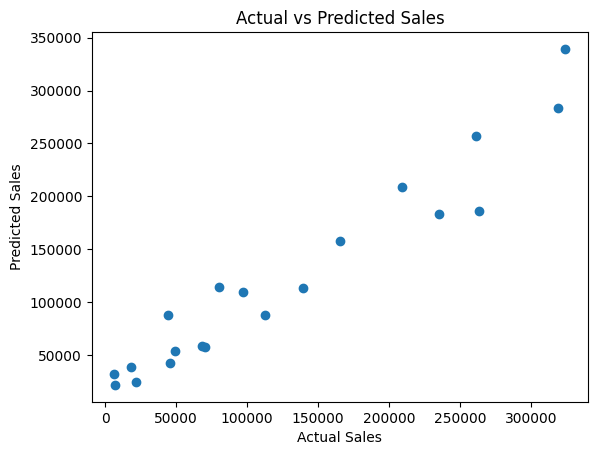

In [25]:
plt.scatter(y_test, rf_preds)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

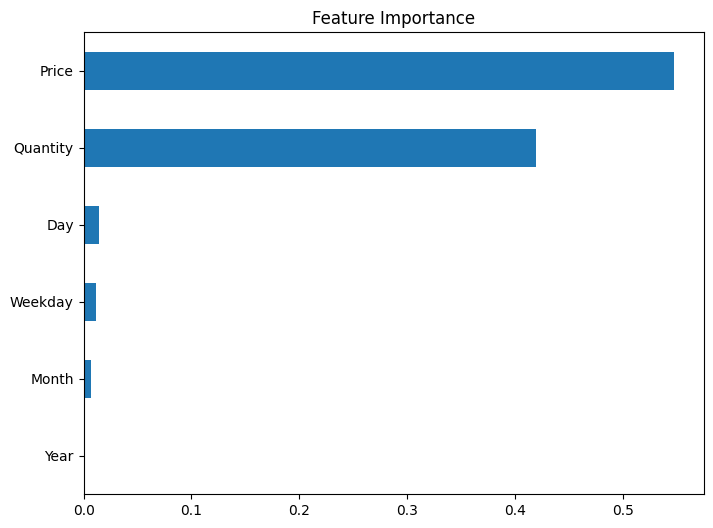

In [26]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

## Key Insights

Quantity and Price strongly influence total sales.

Certain months show higher purchasing activity indicating seasonal demand.

Regional differences suggest location-specific marketing opportunities.

## Business Recommendations

Increase stock levels during high-demand months.

Focus promotions on high-performing regions.

Adjust pricing strategies based on demand patterns.

In [27]:
pickle.dump(
    rf_model,
    open("sales_model.pkl", "wb")
)